# **Evaluating email acquisition effectiveness through quasi-experimental analysis**

## *Does acquisition via the Email channel lead to higher customer revenue than other acquisition channels?*

#### Analysis Summary

This analysis estimates the impact of Email acquisition on customer revenue using Propensity Score Matching (PSM). Since users were not randomly assigned to acquisition channels, the method creates comparable treatment and control groups by matching Email-acquired users with similar Non-Email users based on observed characteristics (age, gender, country, and state).

After matching 4,995 Email users with 4,995 comparable control users, the estimated Average Treatment Effect on the Treated (ATT) was **-$1.34**. This indicates that Email-acquired users generated slightly lower average revenue than matched Non-Email users. However, the effect was **not statistically significant** (p = 0.61), meaning there is no strong evidence that Email acquisition had a measurable impact on revenue in this dataset.

#### Limitations

The analysis is based on observational data rather than a randomized experiment. Therefore, PSM can only control for observed characteristics included in the model and cannot remove bias from unobserved factors such as customer intent, prior engagement, or marketing exposure. Additionally, the dataset is synthetic, meaning the observed relationships may not fully reflect real-world customer behaviour.

#### Why only age, gender, country and federal state as covariates?

For the propensity score model, only variables that were known prior to the treatment (email acquisition) were deliberately used. In other words, purely demographic characteristics. Behavioural variables such as order frequency, sessions or product interactions were deliberately excluded, as these arise after the acquisition and may therefore already be influenced by the treatment itself (‘post-treatment bias’). If such variables were included in the propensity score model, parts of the actual treatment effect would be controlled for, thereby distorting the ATT estimate rather than improving it. 
The selection of covariates thus follows the basic principle of PSM: to include only confounders that can influence both treatment allocation and the outcome, without themselves being a result of the treatment.


In [1]:
#import traceback
from google.cloud import bigquery

#try:
#    client = bigquery.Client()
#    print("OK")
#except Exception:
 #   traceback.print_exc()

In [2]:
import pandas as pd
from pathlib import Path

# Folder with the CSV files
data_path = Path("data")

# Load data
users = pd.read_csv(data_path / "users.csv")
orders = pd.read_csv(data_path / "orders.csv")
order_items = pd.read_csv(data_path / "order_items.csv")
products = pd.read_csv(data_path / "products.csv")
inventory_items = pd.read_csv(data_path / "inventory_items.csv")
distribution_centers = pd.read_csv(data_path / "distribution_centers.csv")
events = pd.read_csv(data_path / "events.csv")

datasets = {
    "users": users,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "inventory_items": inventory_items,
    "distribution_centers": distribution_centers,
    "events": events,
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(f"Shape: {df.shape}")
    display(df.head())

/var/folders/hc/gn3lcvh11_z2j1rdgtttqx700000gn/T/ipykernel_97530/2113892980.py:8: DtypeWarning: Columns (0: postal_code) have mixed types. Specify dtype option on import or set low_memory=False.
  users = pd.read_csv(data_path / "users.csv")



users
Shape: (100000, 16)


,id,first_name,last_name,email,age,gender,state,street_address,postal_code,city,country,latitude,longitude,traffic_source,created_at,user_geom
0,89423,Susan,Guerrero,susanguerrero@example.com,26,F,Acre,6835 Dana Park,69980-000,NaN,Brasil,-8.065346,-72.870949,Search,2023-06-02 12:00:00+00:00,POINT(-72.87094866 -8.065346116)
1,42466,Rachel,Moore,rachelmoore@example.com,52,F,Acre,67836 Jonathan Light,69980-000,NaN,Brasil,-8.065346,-72.870949,Search,2022-04-02 00:02:00+00:00,POINT(-72.87094866 -8.065346116)
2,19514,Kendra,Hansen,kendrahansen@example.net,18,F,Acre,6526 Moore Cliffs Apt. 206,69980-000,NaN,Brasil,-8.065346,-72.870949,Search,2025-05-07 07:06:00+00:00,POINT(-72.87094866 -8.065346116)
3,69070,Janet,Sanchez,janetsanchez@example.com,68,F,Acre,7293 Michael Loop,69980-000,NaN,Brasil,-8.065346,-72.870949,Organic,2020-10-01 17:51:00+00:00,POINT(-72.87094866 -8.065346116)
4,55317,Julia,Miller,juliamiller@example.org,22,F,Acre,1303 Dorsey Overpass,69980-000,NaN,Brasil,-8.065346,-72.870949,Search,2025-03-30 09:22:00+00:00,POINT(-72.87094866 -8.065346116)



orders
Shape: (124866, 9)


,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item
0,16,16,Cancelled,F,2022-06-17 09:31:43+00:00,NaN,NaN,NaN,2
1,17,17,Cancelled,F,2025-07-17 07:17:43+00:00,NaN,NaN,NaN,2
2,51,43,Cancelled,F,2025-08-04 11:02:12+00:00,NaN,NaN,NaN,2
3,63,52,Cancelled,F,2024-07-31 07:43:16+00:00,NaN,NaN,NaN,1
4,69,55,Cancelled,F,2020-03-26 09:33:19+00:00,NaN,NaN,NaN,1


...

,id,product_id,created_at,sold_at,cost,product_category,product_name,product_brand,product_retail_price,product_department,product_sku,product_distribution_center_id
0,16219,13844,2024-08-23 06:32:36+00:00,2024-09-17 04:35:36+00:00,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7
1,16220,13844,2022-06-08 06:31:00+00:00,NaN,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7
2,16221,13844,2024-12-26 09:54:00+00:00,NaN,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7
3,153946,13844,2023-06-24 10:48:40+00:00,2023-08-17 20:45:40+00:00,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7
4,153947,13844,2023-10-02 17:35:00+00:00,NaN,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7



distribution_centers
Shape: (10, 5)


,id,name,latitude,longitude,distribution_center_geom
0,10,Savannah GA,32.0167,-81.1167,POINT(-81.1167 32.0167)
1,3,Houston TX,29.7604,-95.3698,POINT(-95.3698 29.7604)
2,7,Philadelphia PA,39.9500,-75.1667,POINT(-75.1667 39.95)
3,5,New Orleans LA,29.9500,-90.0667,POINT(-90.0667 29.95)
4,8,Mobile AL,30.6944,-88.0431,POINT(-88.0431 30.6944)



events
Shape: (2423031, 13)


,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type
0,1672534,NaN,3,1fa64b1e-224b-48ed-8cc9-9710b0ae789b,2019-01-25 17:22:00 UTC,134.154.48.98,São Paulo,São Paulo,02675-031,Safari,YouTube,/cancel,cancel
1,1359078,NaN,3,fe0d658d-356c-4483-8e1d-c262cc5665a9,2025-11-04 15:13:00 UTC,157.224.64.171,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel
2,1451529,NaN,3,b7228d74-7e35-428d-87a2-8bf1ff6c86d9,2025-11-24 15:07:00 UTC,53.207.175.24,São Paulo,São Paulo,02675-031,Firefox,Email,/cancel,cancel
3,1462213,NaN,3,f679488e-f5ac-4c0f-b237-848d9bc05f63,2020-10-22 08:30:00 UTC,165.39.234.227,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel
4,1964332,NaN,3,dcd8177f-bf3b-4e8b-824b-9eb0b50c38f8,2022-02-16 09:18:00 UTC,49.44.193.210,São Paulo,São Paulo,02675-031,Chrome,Adwords,/cancel,cancel


## 1. Data Checks

In [ ]:
users.info()
orders.info()
order_items.info()
events.info()

users.isna().sum()
orders.isna().sum()
events.isna().sum()

users.describe(include="all")

## 2. Feature Engineering

### 2.1 Unit of Analysis

Each row in the feature table represents one user.

The following feature table transforms raw e-commerce data into a structured user level dataset. It aggregates orders, revenue, sessions, product interactions and customer attributes, to generate predictive features used for Propensity Score Matching and downstream ML applications.


.count() counts non-missing (non-NaN) values.
.size (attribute) returns the total number of elements, including missing values.

| Feature            | Meaning                              | Use case                                     |
| ------------------ | ------------------------------------ | -------------------------------------------- |
| `user_id`          | unique user ID                       | identifier; do not use as a model feature   |
| `age`              | customer age                         | control variable                             |
| `gender`           | gender                               | control variable                             |
| `country`, `state` | geographic factors                   | control variables                            |
| `traffic_source`   | acquisition channel                  | treatment basis                              |
| `total_orders`     | number of orders                     | purchase behavior                            |
| `total_revenue`    | total revenue                        | outcome / LTV feature                        |
| `avg_order_value`  | average order value                  | purchase quality                             |
| `total_sessions`   | number of sessions                   | engagement                                   |
| `product_views`    | product interest                     | intent feature                               |
| `cart_views`       | cart interactions                    | purchase intent                              |
| `purchase_events`  | purchase actions                     | conversion                                   |
| `recency`          | days since last order                | customer activity                            |
| `frequency`        | purchase frequency                   | customer loyalty                             |
| `treatment`        | treatment group (here Email traffic) | target variable for propensity model         |
| `outcome`          | outcome variable (here revenue)      | effect measurement                           |


In [ ]:
# ----------------------------
# Convert date fields
# ----------------------------

for df in [users, orders, order_items, events]:
    if "created_at" in df.columns:
        df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")

# ----------------------------
# Orders per user
# ----------------------------

# How many distinct orders has a user made?
orders_per_user = (
    orders
    .groupby("user_id")
    .agg(total_orders=("order_id", "nunique"))
    .reset_index()
)

# ----------------------------
# Revenue
# ----------------------------

revenue = (
    order_items
    .groupby("user_id")
    .agg(total_revenue=("sale_price", "sum"))
    .reset_index()
)

# ----------------------------
# Average order value
# ----------------------------

avg_order_value = (
    order_items
    .groupby("user_id")
    .agg(avg_order_value=("sale_price", "mean"))
    .reset_index()
)

# ----------------------------
# Average order value per order (basket size)
# ----------------------------

avg_items_per_order = (
    order_items
    .groupby(["user_id", "order_id"])
    .size()
    .groupby("user_id")
    .mean()
    .reset_index(name="avg_items_per_order")
)

# ----------------------------
# Sessions
# ----------------------------

sessions = (
    events
    .groupby("user_id")
    .agg(total_sessions=("session_id", "nunique"))
    .reset_index()
)

# ----------------------------
# Events per session
# ----------------------------

avg_events_per_session = (
    events
    .groupby(["user_id", "session_id"])
    .size()
    .groupby("user_id")
    .mean()
    .reset_index(name="avg_events_per_session")
)

# ----------------------------
# Product views
# ----------------------------

product_views = (
    events[events["event_type"] == "product"]
    .groupby("user_id")
    .size()
    .reset_index(name="product_views")
)

# ----------------------------
# Cart views
# ----------------------------

cart_views = (
    events[events["event_type"] == "cart"]
    .groupby("user_id")
    .size()
    .reset_index(name="cart_views")
)

# ----------------------------
# Purchase events
# ----------------------------

purchase_events = (
    events[events["event_type"] == "purchase"]
    .groupby("user_id")
    .size()
    .reset_index(name="purchase_events")
)

# ----------------------------
# Recency
# ----------------------------

reference_date = orders["created_at"].max()

recency = (
    orders
    .groupby("user_id")
    .agg(last_order=("created_at", "max"))
    .reset_index()
)

recency["recency"] = (
    reference_date - recency["last_order"]
).dt.days

recency = recency[["user_id", "recency"]]

# ----------------------------
# Frequency
# ----------------------------

frequency = (
    orders
    .groupby("user_id")
    .agg(frequency=("order_id", "count"))
    .reset_index()
)

# ----------------------------
# Create feature table
# ----------------------------

feature_table = (
    users.rename(columns={"id": "user_id"})
    [["user_id",
      "age",
      "gender",
      "country",
      "state",
      "traffic_source"]]
)

feature_table = (
    feature_table
    .merge(orders_per_user, on="user_id", how="left")
    .merge(revenue, on="user_id", how="left")
    .merge(avg_order_value, on="user_id", how="left")
    .merge(avg_items_per_order, on="user_id", how="left")
    .merge(sessions, on="user_id", how="left")
    .merge(avg_events_per_session, on="user_id", how="left")
    .merge(product_views, on="user_id", how="left")
    .merge(cart_views, on="user_id", how="left")
    .merge(purchase_events, on="user_id", how="left")
    .merge(recency, on="user_id", how="left")
    .merge(frequency, on="user_id", how="left")
)

# ----------------------------
# Fill missing values
# ----------------------------

feature_table = feature_table.fillna(0)

# ----------------------------
# Conversion rate
# ----------------------------

feature_table["conversion_rate"] = (
    feature_table["purchase_events"]
    / feature_table["product_views"]
).fillna(0)

# ----------------------------
# Cart abandonment rate
# ----------------------------

feature_table["cart_abandonment_rate"] = (
    (
        feature_table["cart_views"]
        - feature_table["purchase_events"]
    )
    / feature_table["cart_views"]
).fillna(0)

# ----------------------------
# Treatment variable
# ----------------------------

feature_table["treatment"] = (
    feature_table["traffic_source"] == "Email"
).astype(int)


(100000, 21)


,user_id,age,gender,country,state,traffic_source,total_orders,total_revenue,avg_order_value,avg_items_per_order,...,avg_events_per_session,product_views,cart_views,purchase_events,recency,frequency,conversion_rate,cart_abandonment_rate,treatment,outcome
0,89423,26,F,Brasil,Acre,Search,0.0,0.00,0.000,0.000000,...,7.00,4.0,4.0,2.0,0.0,0.0,0.5,0.5,0,0.00
1,42466,52,F,Brasil,Acre,Search,1.0,63.97,31.985,2.000000,...,8.75,10.0,10.0,4.0,60.0,1.0,0.4,0.6,0,63.97
2,19514,18,F,Brasil,Acre,Search,3.0,130.54,26.108,1.666667,...,0.00,0.0,0.0,0.0,67.0,3.0,0.0,0.0,0,130.54
3,69070,68,F,Brasil,Acre,Organic,1.0,22.50,22.500,1.000000,...,5.00,2.0,2.0,2.0,1543.0,1.0,1.0,0.0,0,22.50
4,55317,22,F,Brasil,Acre,Search,1.0,10.50,10.500,1.000000,...,5.00,3.0,3.0,3.0,255.0,1.0,1.0,0.0,0,10.50


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   user_id                 100000 non-null  int64  
 1   age                     100000 non-null  int64  
 2   gender                  100000 non-null  str    
 3   country                 100000 non-null  str    
 4   state                   100000 non-null  str    
 5   traffic_source          100000 non-null  str    
 6   total_orders            100000 non-null  float64
 7   total_revenue           100000 non-null  float64
 8   avg_order_value         100000 non-null  float64
 9   avg_items_per_order     100000 non-null  float64
 10  total_sessions          100000 non-null  float64
 11  avg_events_per_session  100000 non-null  float64
 12  product_views           100000 non-null  float64
 13  cart_views              100000 non-null  float64
 14  purchase_events         100000 n

,user_id,age,gender,country,state,traffic_source,total_orders,total_revenue,avg_order_value,avg_items_per_order,...,avg_events_per_session,product_views,cart_views,purchase_events,recency,frequency,conversion_rate,cart_abandonment_rate,treatment,outcome
count,100000.000000,100000.00000,100000,100000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
unique,NaN,NaN,2,16,228,5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,M,China,Guangdong,Search,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,50087,33683,5317,69848,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,50000.500000,41.05680,NaN,NaN,NaN,NaN,1.248660,108.301907,47.811111,1.164790,...,4.981528,3.430300,3.430300,1.812340,452.569160,1.248660,0.632740,0.168740,0.049950,108.301907
std,28867.657797,17.02757,NaN,NaN,NaN,NaN,0.991624,135.562673,54.045438,0.867833,...,3.057185,4.866183,4.866183,1.693078,551.308258,0.991624,0.396527,0.255186,0.217843,135.562673
min,1.000000,12.00000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25000.750000,26.00000,NaN,NaN,NaN,NaN,1.000000,16.625000,15.000000,1.000000,...,5.000000,1.000000,1.000000,1.000000,12.000000,1.000000,0.333333,0.000000,0.000000,16.625000
50%,50000.500000,41.00000,NaN,NaN,NaN,NaN,1.000000,61.980000,37.990002,1.000000,...,5.000000,1.000000,1.000000,1.000000,229.000000,1.000000,0.666667,0.000000,0.000000,61.980000
75%,75000.250000,56.00000,NaN,NaN,NaN,NaN,2.000000,151.949997,63.725000,1.500000,...,6.333333,4.000000,4.000000,3.000000,704.000000,2.000000,1.000000,0.400000,0.000000,151.949997


In [5]:
events["event_type"].value_counts()

event_type
product       843030
cart          593118
department    592743
purchase      181234
cancel        125180
home           87726
Name: count, dtype: int64

## 3. Study Design

This study uses observational e-commerce data. Because users were not randomly assigned to acquisition channels, a quasi-experimental design based on Propensity Score Matching (PSM) is applied to reduce selection bias before estimating the Average Treatment Effect on the Treated (ATT).

Users were not randomly assigned to acquisition channels. Therefore, Email acquisition is treated as an observational treatment rather than a randomized intervention.

In [ ]:
from sklearn.linear_model import LogisticRegression

# ==========================================================
# PROPENSITY SCORE MODEL
# Goal:
# Estimate each user's probability of belonging to the
# Email treatment group based on observed characteristics.
#
# This probability is called the Propensity Score and will
# later be used for matching treated and untreated users.
# ==========================================================


# ----------------------------------------------------------
# Question:
# Which variables should explain treatment assignment?
#
# Why?
# Only pre-treatment covariates should be used.
# Here we use demographic characteristics.
# ----------------------------------------------------------

propensity_features = feature_table[
    [
        "age",
        "gender",
        "country",
        "state"
    ]
].copy()


# ----------------------------------------------------------
# Question:
# Why do we encode categorical variables?
#
# Logistic Regression only works with numerical input.
# Therefore, categorical variables are transformed into
# binary dummy variables.
# ----------------------------------------------------------

propensity_features = pd.get_dummies(
    propensity_features,
    columns=["gender", "country", "state"],
    drop_first=True
)


# ----------------------------------------------------------
# Question:
# What should the model predict?
#
# Treatment = 1
# Control   = 0
#
# Here:
# 1 = Email acquisition
# 0 = Other acquisition channels
# ----------------------------------------------------------

propensity_target = feature_table["treatment"]


# ----------------------------------------------------------
# Question:
# Which model estimates the propensity score?
#
# Logistic Regression estimates:
#
# P(Treatment = 1 | X)
#
# = Probability that a user belongs to the Email group
# given the observed covariates.
# ----------------------------------------------------------

logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# ----------------------------------------------------------
# Question:
# What happens during training?
#
# The model learns the relationship between
#
# X (Age, Gender, Country, State)
#
# and
#
# Treatment (Email vs. Non-Email).
# ----------------------------------------------------------

logreg.fit(
    propensity_features,
    propensity_target
)


# ----------------------------------------------------------
# Question:
# What are Propensity Scores?
#
# predict_proba() returns two probabilities:
#
# [ P(class=0), P(class=1) ]
#
# In this project:
#
# class 0 = Not Email
# class 1 = Email
#
# Example:
#
# [0.18 , 0.82]
#
# means:
#
# 18% probability that the user belongs
# to the Control group.
#
# 82% probability that the user belongs
# to the Email Treatment group.
#
# We therefore keep only column [:,1].
# ----------------------------------------------------------

feature_table["propensity_score"] = (
    logreg.predict_proba(propensity_features)[:,1]
)


# ----------------------------------------------------------
# Question:
# Why store the propensity score?
#
# Each user now receives a probability between 0 and 1.
#
# Later we will match users with similar propensity scores
# before comparing their revenue.
# ----------------------------------------------------------


# ----------------------------------------------------------
# Overview
# ----------------------------------------------------------

print("Propensity model trained successfully.")
print(f"Number of users: {len(feature_table)}")

print(
    feature_table[
        [
            "user_id",
            "treatment",
            "propensity_score"
        ]
    ]
)

Propensity model trained successfully.
Number of users: 100000
       user_id  treatment  propensity_score
0        89423          0          0.044229
1        42466          0          0.045156
2        19514          0          0.043947
3        69070          0          0.045736
4        55317          0          0.044088
...        ...        ...               ...
99995    61563          1          0.058590
99996    15808          0          0.056749
99997    21438          0          0.058636
99998    34886          0          0.056928
99999    40461          0          0.057333

[100000 rows x 3 columns]


Example: For this user, the estimated propensity score is 0.0442, corresponding to a 4.42% probability of belonging to the Email treatment group given the observed covariates (age, gender, country, and state). Since the observed treatment value is 0, the user was not acquired via the Email channel. The low propensity score indicates that, based on the available characteristics, Email acquisition was considered unlikely for this user.

Why is this important? The propensity score is not the final result of the analysis. Instead, it is used in the next step of Propensity Score Matching (PSM) to match treated users (Email) with untreated users (Non-Email) who have a similar probability of receiving the treatment. This creates more comparable groups before estimating the treatment effect on customer revenue.

Observation: Most estimated propensity scores are close to 0.04–0.05, suggesting that only about 4–5% of users belong to the Email treatment group. This may indicate that Email acquisition is largely independent of the demographic variables included in the model, or that age, gender, country, and state provide only limited information for predicting whether a user was acquired through the Email channel. Consequently, additional pre-treatment covariates (if available) could improve the propensity model by better explaining treatment assignment.

In [7]:
feature_table["treatment"].value_counts(normalize=True)

treatment
0    0.95005
1    0.04995
Name: proportion, dtype: float64

Approximately 5% of users belong to the Email treatment group, while 95% were acquired through other channels. This indicates a highly imbalanced treatment assignment, which explains why many estimated propensity scores are close to 0.05.

In this dataset, approximately 5% of users belong to the Email treatment group, while 95% belong to the control group. The estimated propensity scores are therefore concentrated around this baseline probability. This suggests that the selected demographic variables provide limited information for predicting Email acquisition assignment.

Since the dataset is observational and users were not randomly assigned to acquisition channels, the results should be interpreted as a quasi-experimental adjustment of observed differences rather than as definitive causal evidence. The following matching step will evaluate whether comparable treatment and control users can be identified before estimating differences in customer revenue.

## 4. Common Support Check

In [8]:
# ----------------------------------------------------------
# Common Support Check
#
# Question:
# Do Treatment and Control users have overlapping
# propensity score ranges?
#
# Why?
# Matching is only meaningful when users from both groups
# have similar probabilities of receiving the treatment.
# ----------------------------------------------------------

common_support = (
    feature_table
    .groupby("treatment")["propensity_score"]
    .agg(["min", "max", "mean", "median", "count"])
)

common_support


,min,max,mean,median,count
treatment,,,,,
0,0.022628,0.105375,0.049921,0.050034,95005
1,0.023265,0.105375,0.051734,0.050852,4995


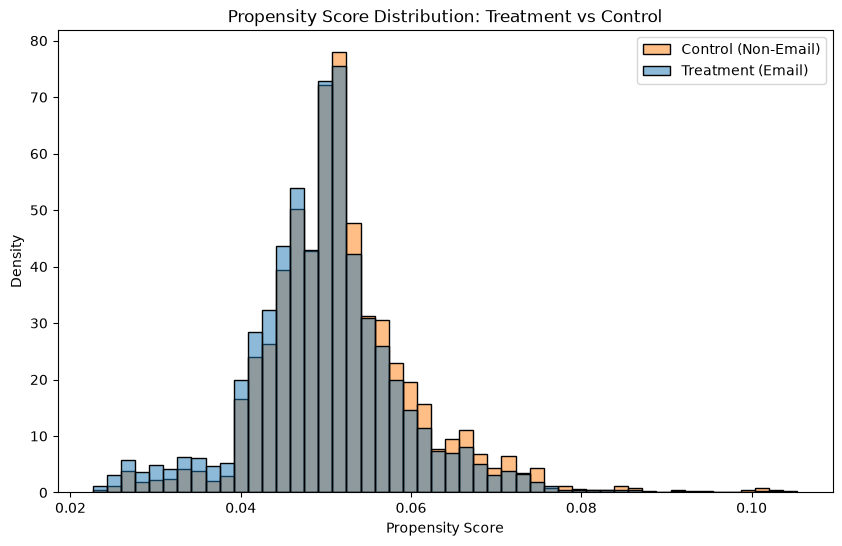

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


# ----------------------------------------------------------
# Question:
# Do Treatment and Control groups have similar propensity
# score distributions?
#
# Why?
# Visual inspection of overlap (common support).
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

sns.histplot(
    data=feature_table,
    x="propensity_score",
    hue="treatment",
    bins=50,
    stat="density",
    common_norm=False,
    alpha=0.5
)

plt.title(
    "Propensity Score Distribution: Treatment vs Control"
)

plt.xlabel(
    "Propensity Score"
)

plt.ylabel(
    "Density"
)

plt.legend(
    labels=[
        "Control (Non-Email)",
        "Treatment (Email)"
    ]
)

plt.show()

In [10]:
# ----------------------------------------------------------
# Question:
# What is the overlapping propensity score range?
#
# Why?
# Users outside this range cannot be reliably matched.
# ----------------------------------------------------------

treatment_scores = feature_table.loc[
    feature_table["treatment"] == 1,
    "propensity_score"
]

control_scores = feature_table.loc[
    feature_table["treatment"] == 0,
    "propensity_score"
]


lower_bound = max(
    treatment_scores.min(),
    control_scores.min()
)

upper_bound = min(
    treatment_scores.max(),
    control_scores.max()
)


print(
    f"Common support range: {lower_bound:.4f} - {upper_bound:.4f}"
)

Common support range: 0.0233 - 0.1054


The propensity score distributions of the treatment and control groups show substantial overlap. The estimated propensity scores range from 0.0233 to 0.1054 within the common support region, meaning that users in both groups have comparable probabilities of receiving the Email treatment.

This indicates that it is possible to identify similar users from the control group for users in the treatment group. Therefore, the dataset provides sufficient overlap for applying Propensity Score Matching.

Users outside this overlapping range would not have suitable counterparts and would typically be excluded from the matching procedure.

## 5. Propensity Score Matching

In [11]:
import numpy as np
from sklearn.neighbors import NearestNeighbors


# ==========================================================
# PROPENSITY SCORE MATCHING
#
# Goal:
# Match each Email user with the most similar Non-Email user
# based on the estimated propensity score.
#
# Method:
# 1:1 Nearest Neighbor Matching
#
# ==========================================================


# ----------------------------------------------------------
# Question:
# Which users belong to treatment and control groups?
#
# Why?
# We need to create two separate pools of users
# for matching.
# ----------------------------------------------------------

treatment_group = feature_table[
    feature_table["treatment"] == 1
].copy()


control_group = feature_table[
    feature_table["treatment"] == 0
].copy()


print(
    "Treatment users:",
    len(treatment_group)
)

print(
    "Control users:",
    len(control_group)
)


# ----------------------------------------------------------
# Question:
# What variable defines similarity?
#
# Why?
# Users with similar propensity scores have similar
# probability of receiving the Email treatment.
# ----------------------------------------------------------

X_control = control_group[
    ["propensity_score"]
]


X_treatment = treatment_group[
    ["propensity_score"]
]


# ----------------------------------------------------------
# Question:
# How do we find the closest control user?
#
# NearestNeighbors searches the control group and returns
# the user with the smallest distance in propensity score.
# ----------------------------------------------------------

nn = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean"
)


nn.fit(X_control)


# Find closest control user for every treatment user

distances, indices = nn.kneighbors(
    X_treatment
)


# ----------------------------------------------------------
# Question:
# What did the algorithm return?
#
# distances:
# Difference between treatment score and matched
# control score.
#
# indices:
# Position of the matched control user.
# ----------------------------------------------------------


matched_control = control_group.iloc[
    indices.flatten()
].copy()


# ----------------------------------------------------------
# Question:
# How do we create the final matched dataset?
#
# We combine:
# - all Email users
# - their matched Non-Email users
# ----------------------------------------------------------

matched_data = pd.concat(
    [
        treatment_group.reset_index(drop=True),
        matched_control.reset_index(drop=True)
    ]
)


# ----------------------------------------------------------
# Add matching information
#
# Question:
# How do we store the matching distance?
#
# The distance is calculated between each treatment user
# and its matched control user.
#
# We assign:
# - NaN to treatment users
# - The calculated distance to matched control users
# ----------------------------------------------------------

treatment_group["match_distance"] = np.nan

matched_control["match_distance"] = distances.flatten()


# ----------------------------------------------------------
# Question:
# How do we create the final matched dataset?
#
# We combine:
# - all Email users
# - their matched Non-Email users
#
# The resulting dataset contains one matched pair for each
# treatment user.
# ----------------------------------------------------------

matched_data = pd.concat(
    [
        treatment_group.reset_index(drop=True),
        matched_control.reset_index(drop=True)
    ],
    ignore_index=True
)


# ----------------------------------------------------------
# Overview
# ----------------------------------------------------------

print(
    "Matched dataset size:",
    matched_data.shape
)
print(
    matched_data[
        [
            "user_id",
            "treatment",
            "propensity_score",
            "match_distance",
            "outcome"
        ]
    ]
)



Treatment users: 4995
Control users: 95005
Matched dataset size: (9990, 23)
      user_id  treatment  propensity_score  match_distance     outcome
0       17603          1          0.033828             NaN  427.489998
1       54064          1          0.035179             NaN  409.870003
2       34004          1          0.033637             NaN   84.989998
3       96068          1          0.034937             NaN   80.340001
4        8423          1          0.035607             NaN   34.299999
...       ...        ...               ...             ...         ...
9985    71163          0          0.055905             0.0   13.230000
9986    16839          0          0.056973             0.0   36.990002
9987     6995          0          0.057902             0.0   43.619999
9988    90138          0          0.056614             0.0  243.000000
9989    92087          0          0.058590             0.0   48.870002

[9990 rows x 5 columns]


## 6. Matching Quality

In [12]:
print(distances[:10])

[[1.13509244e-06]
 [0.00000000e+00]
 [0.00000000e+00]
 [6.26728589e-08]
 [0.00000000e+00]
 [5.01394236e-06]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]]


Matching Quality: The nearest neighbor matching procedure resulted in extremely small matching distances, typically close to zero. This indicates that, for nearly every treated user, the algorithm identified a control user with an almost identical propensity score. The large control group and the substantial overlap in propensity score distributions allowed for high-quality matches based on the observed covariates.

## 7. Balance Check

In [ ]:
# ==========================================================
# BALANCE CHECK
#
# Goal:
# Evaluate whether Propensity Score Matching created
# comparable treatment and control groups.
#
# Why?
# Matching should reduce observable differences between
# treated and untreated users before estimating the
# treatment effect.
# ==========================================================


# ----------------------------------------------------------
# Question:
# Are numerical covariates balanced after matching?
#
# Why?
# Similar averages indicate that treatment and control
# users are comparable with respect to observed variables.
# ----------------------------------------------------------

numeric_balance = (
    matched_data
    .groupby("treatment")[
        [
            "age",
            "propensity_score"
        ]
    ]
    .mean()
)

print("Average numerical covariates after matching:\n")
print(numeric_balance)


# ----------------------------------------------------------
# Question:
# Is gender balanced after matching?
#
# Why?
# Compare the distribution of gender between the two groups.
# ----------------------------------------------------------

gender_balance = pd.crosstab(
    matched_data["treatment"],
    matched_data["gender"],
    normalize="index"
)

print("\nGender distribution:\n")
print(gender_balance)


# ----------------------------------------------------------
# Question:
# Is country balanced after matching?
#
# Why?
# Compare the relative country frequencies.
# ----------------------------------------------------------

country_balance = pd.crosstab(
    matched_data["treatment"],
    matched_data["country"],
    normalize="index"
)

print("\nCountry distribution:\n")
print(country_balance)


# ----------------------------------------------------------
# Question:
# Is state balanced after matching?
#
# Why?
# Compare the relative state frequencies.
# ----------------------------------------------------------

state_balance = pd.crosstab(
    matched_data["treatment"],
    matched_data["state"],
    normalize="index"
)

print("\nState distribution:\n")
print(state_balance)

Average numerical covariates after matching:

                 age  propensity_score
treatment                             
0          41.343143          0.051734
1          41.341542          0.051734

Gender distribution:

gender            F         M
treatment                    
0          0.488889  0.511111
1          0.490290  0.509710

Country distribution:

country    Australia   Belgium    Brasil     China    France   Germany  \
treatment                                                                
0           0.023824  0.013413  0.143744  0.347548  0.044645  0.043443   
1           0.023023  0.014214  0.143544  0.342943  0.045245  0.044044   

country       Japan    Poland  South Korea     Spain  United Kingdom  \
treatment                                                              
0          0.016016  0.002002     0.052653  0.038639        0.044444   
1          0.019219  0.002803     0.053453  0.038639        0.044845   

country    United States  
treatment         

## Balance Check Results


The balance check indicates that the propensity score matching procedure successfully created comparable treatment and control groups.

- Numerical covariates: The average values of the numerical variables are nearly identical.
The negligible differences suggest that the matched users have very similar demographic characteristics and estimated probabilities of receiving the Email treatment.

- Categorical covariates: The distributions of gender, country, and state are also highly comparable between the treatment and matched control groups. 

Overall, the balance check suggests that the matching procedure substantially reduced observable differences between the treatment and control groups. Consequently, the matched users can be considered comparable with respect to the observed pre-treatment covariates. This provides a more suitable basis for estimating the association between Email acquisition and customer revenue.

## 8. Average Treatment Effect on the Treated (ATT)

The estimated ATT represents the average difference in customer revenue between matched Email and Non-Email users after adjusting for the observed covariates. Because the analysis is based on observational data rather than a randomized experiment, the result should be interpreted as an adjusted association rather than definitive causal evidence.

In [ ]:
# ==========================================================
# AVERAGE TREATMENT EFFECT ON THE TREATED (ATT)
#
# Goal:
# Estimate the difference in average customer revenue
# between matched Email users (treatment) and matched
# Non-Email users (control).
#
# Why?
# After matching, both groups are comparable with respect
# to the observed covariates.
#
# The remaining difference in revenue is the estimated
# Average Treatment Effect on the Treated (ATT).
# ==========================================================


# ----------------------------------------------------------
# Question:
# What is the average revenue of the treatment group?
# ----------------------------------------------------------

treatment_revenue = matched_data.loc[
    matched_data["treatment"] == 1,
    "outcome"
].mean()


# ----------------------------------------------------------
# Question:
# What is the average revenue of the matched control group?
# ----------------------------------------------------------

control_revenue = matched_data.loc[
    matched_data["treatment"] == 0,
    "outcome"
].mean()


# ----------------------------------------------------------
# Question:
# What is the estimated treatment effect?
#
# ATT =
#
# Average Revenue (Treatment) - Average Revenue (Matched Control)
# ----------------------------------------------------------

att = treatment_revenue - control_revenue


# ----------------------------------------------------------
# Overview
# ----------------------------------------------------------

print("========================================")
print("Average Treatment Effect on the Treated")
print("========================================\n")

print(f"Treatment users : {len(treatment_group)}")
print(f"Matched controls: {len(matched_control)}\n")

print(f"Average Revenue (Treatment): ${treatment_revenue:.2f}")
print(f"Average Revenue (Control):   ${control_revenue:.2f}\n")

print(f"Estimated ATT: ${att:.2f}")

Average Treatment Effect on the Treated

Treatment users : 4995
Matched controls: 4995

Average Revenue (Treatment): $107.57
Average Revenue (Control):   $108.91

Estimated ATT: $-1.34


**Treatment < Control**

After matching users with similar observed characteristics, customers acquired through the Email channel generated, on average, $1.34 less revenue than comparable users acquired through other channels (estimated ATT = −$1.34).

Because the analysis is based on observational data, this result should be interpreted as an adjusted association rather than definitive causal evidence — unobserved confounding factors may still influence both treatment assignment and customer revenue.

## 9. Statistical Significance

In [ ]:
from scipy.stats import ttest_rel

# ==========================================================
# STATISTICAL TEST FOR ATT
#
# Goal:
# Test whether the revenue difference between matched
# treatment and control users is statistically significant.
#
# Method:
# Paired t-test
#
# Why?
# Each Email user has a specific matched Non-Email user.
# Therefore, observations are paired.
# ==========================================================


# ----------------------------------------------------------
# Question:
# What are the revenue values of the treatment group?
#
# Only matched Email users are included.
# ----------------------------------------------------------

treatment_outcomes = matched_data[
    matched_data["treatment"] == 1
]["outcome"].values


# ----------------------------------------------------------
# Question:
# What are the revenue values of the matched control group?
#
# These are the corresponding comparison users.
# ----------------------------------------------------------

control_outcomes = matched_data[
    matched_data["treatment"] == 0
]["outcome"].values


# ----------------------------------------------------------
# Question:
# Is the average revenue difference statistically significant?
#
# H0:
# No difference between Email and Control revenue
#
# H1:
# Revenue differs between Email and Control
# ----------------------------------------------------------

t_stat, p_value = ttest_rel(
    treatment_outcomes,
    control_outcomes
)


# ----------------------------------------------------------
# Calculate confidence interval for the ATT difference
# ----------------------------------------------------------

differences = treatment_outcomes - control_outcomes

att = differences.mean()

std_error = differences.std(ddof=1) / np.sqrt(len(differences))

confidence_interval = (
    att - 1.96 * std_error,
    att + 1.96 * std_error
)


# ----------------------------------------------------------
# Results
# ----------------------------------------------------------

print("========================================")
print("ATT Significance Test")
print("========================================\n")

print(f"ATT: ${att:.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

print(
    f"95% Confidence Interval: "
    f"({confidence_interval[0]:.2f}, "
    f"{confidence_interval[1]:.2f})"
)


# ----------------------------------------------------------
# Interpretation
# ----------------------------------------------------------

if p_value < 0.05:
    print(
        "\nResult: The revenue difference is statistically significant."
    )
else:
    print(
        "\nResult: No statistically significant revenue difference detected."
    )


ATT Significance Test

ATT: $-1.34
T-statistic: -0.509
P-value: 0.6109
95% Confidence Interval: (-6.51, 3.83)

Result: No statistically significant revenue difference detected.


## Treatment Effect Results

After applying 1:1 nearest neighbour propensity score matching, the estimated Average Treatment Effect on the Treated (ATT) was −$1.34.

The effect was **not statistically significant** (p = 0.61; 95% CI: −$6.51 to $3.83, which includes zero). The observed revenue difference is consistent with random sampling variation — the null hypothesis of no treatment effect cannot be rejected.

**Interpretation:** matching successfully balanced the observed pre-treatment covariates (age, gender, country, state), providing a more appropriate comparison than a simple average-revenue comparison. This does not establish causality — see Limitations below.

## Limitations of the quasi-experimental study

Although Propensity Score Matching improves comparability between the Email treatment group and the control group, several limitations remain.

1. Observational data

The analysis is based on observational rather than experimental data. Since users were not randomly assigned to acquisition channels, causal conclusions cannot be established with certainty.

2. Unobserved confounding

Propensity Score Matching only adjusts for variables included in the propensity score model. Important factors such as customer purchase intent, previous marketing exposure, browsing behaviour, product preferences, or socioeconomic characteristics were not available and may still confound the estimated treatment effect.

3. Limited covariates

The propensity score model included only demographic characteristics (age, gender, country, and state). If additional pre-treatment variables that influence channel assignment exist but were omitted, some selection bias may remain.

4. Common support assumption

Although substantial overlap between treatment and control users was observed, Propensity Score Matching estimates treatment effects only for users within the region of common support. Therefore, the estimated ATT applies only to users with comparable propensity scores and may not generalise to all customers.

5. Treatment definition

The treatment group consisted of customers acquired through the Email channel, while the control group combined all remaining acquisition channels. Since different acquisition channels may attract customers with different behavioural profiles, the estimated effect represents an average comparison against a heterogeneous control group.

6. Synthetic dataset

The analysis uses the publicly available TheLook eCommerce dataset, which is simulated for educational purposes. Consequently, customer behaviour, acquisition mechanisms, and revenue relationships may differ from those observed in real commercial settings.

## Conclusion

After matching 4,995 Email-acquired customers with 4,995 comparable Non-Email customers, the estimated treatment effect was −$1.34 in average customer revenue — not statistically significant (p = 0.61, 95% CI includes zero).

Propensity Score Matching substantially reduced observable selection bias between the groups, but the analysis is based on observational, synthetic data. The result should be read as an adjusted association under the assumptions of PSM, not as definitive causal evidence: acquisition through the Email channel did not measurably affect customer revenue in this dataset.